# 14 — Learning from Pixels

A camera, a convolutional network, and the world it was not trained in ·
SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/14-vision/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** This week renders
    thousands of camera pictures through EGL, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

It trains three small networks on the CPU, about a minute each.

## The robot opens its eyes

For thirteen weeks the G1 has known only what is inside it: joint
angles, an IMU, and — in simulation — anything we chose to hand it. It
has never known **where anything else is**.

Today it gets a camera, and a network that turns pixels into a
direction.

1.  A camera is two lines of `MjSpec`; the labels come free from the
    simulator.
2.  A convolutional network learns *where the ball is* to about a
    degree.
3.  It fails — badly — on a ball of a different colour. We measure why.
4.  Randomising the training pictures fixes it, at a price.
5.  The network closes a loop: the robot turns to face the ball.

**Layer:** perception feeding Layer 5. The camera is a Layer 2 sensor;
what reads it is learned.

------------------------------------------------------------------------

## Setting up

In [1]:
import importlib.util

# On Colab, upgrade before importing: pip cannot replace a loaded module.
if importlib.util.find_spec("google.colab") is not None:
    %pip install -q --upgrade "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"

import math, time
import numpy as np
import matplotlib.pyplot as plt
import soc4180          # first: it selects the GL backend before mujoco loads
import mujoco
import torch
from soc4180 import vision
from soc4180.render import _new_renderer

torch.manual_seed(0)
torch.set_num_threads(4)
model = vision.camera_model(("red",))
data = mujoco.MjData(model)
mujoco.mj_resetDataKeyframe(model, data, 0)
mujoco.mj_forward(model, data)
cam = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, "head")
print(f"cameras {model.ncam}   mocap bodies {model.nmocap}   camera at height {data.cam_xpos[cam][2]:.2f} m")

cameras 1   mocap bodies 1   camera at height 1.28 m

`vision.camera_model` is the G1 scene plus **two additions** made with
`MjSpec` before compiling: a camera on `torso_link`, and one ball.

The printed height: the camera sits **1.28 m** above the floor, at about
the height of a person’s chin.

------------------------------------------------------------------------

## Colour code for the week

The same colours mean the same things in every equation on these slides:

| symbol | meaning | colour |
|------------------------|------------------------|------------------------|
| ${\color{#3b7dd8}{a,\ e}}$ | a **direction**: azimuth $a$ (left +), elevation $e$ (up +), in radians | <span style="color:#3b7dd8">blue</span> |
| ${\color{#3b7dd8}{X,\ Y,\ Z}}$ | a point in the **camera’s frame**: right, up, forward (depth), in metres | <span style="color:#3b7dd8">blue</span> |
| ${\color{#e8743b}{u,\ v,\ f}}$ | **picture** coordinates: across, down, and the focal length | <span style="color:#e8743b">orange</span> |
| ${\color{#2a9d5c}{w,\ b}}$ | **learned numbers**: a filter’s weights and its bias | <span style="color:#2a9d5c">green</span> |
| ${\color{#c0392b}{L,\ \eta}}$ | the **loss** being made small, and the learning rate | <span style="color:#c0392b">red</span> |
| ${\color{#8e44ad}{g}}$ | the **gain** of the turning loop at the end of the week | <span style="color:#8e44ad">purple</span> |

Three questions, in order: *how does a point in the world land on a
pixel* (geometry), *how does a network read pixels* (convolution), *how
does it learn* (loss and gradient). Then the robot uses the answer, and
we analyse the loop it closes.

------------------------------------------------------------------------

## A camera is a body-fixed frame

``` python
spec = mujoco.MjSpec.from_file(str(soc4180.robot_path()))
spec.body("torso_link").add_camera(name="head", pos=[0.08, 0, 0.45],
                                   xyaxes=[0, -1, 0, 0, 0, 1], fovy=90)
ball = spec.worldbody.add_body(name="ball_red", mocap=True, pos=[1.2, 0, 0.8])
ball.add_geom(type=mujoco.mjtGeom.mjGEOM_SPHERE, size=[0.1, 0, 0],
              rgba=[0.9, 0.1, 0.1, 1], contype=0, conaffinity=0)
model = spec.compile()
```

- A camera is attached to a **body**, like a site: it moves with the
  torso, so when the waist turns, the picture turns.
- MuJoCo cameras look down their own **−z**. `xyaxes` names the camera’s
  x (image right) and y (image up) in the body frame: right = torso −y,
  up = +z, so it looks along +x — forward.
- A **mocap** body has no joint and feels no physics: you move it by
  writing `data.mocap_pos`. `contype = conaffinity = 0` means nothing
  can hit it. It is a target, not an object.

------------------------------------------------------------------------

## What the robot sees

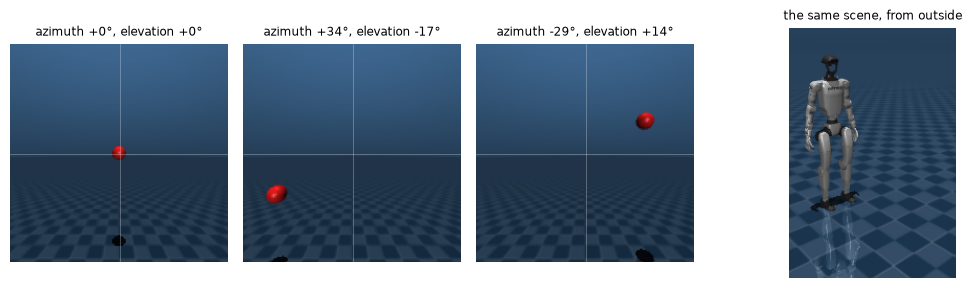

In [2]:
rng = np.random.default_rng(3)
shots = []
with _new_renderer(model, 160, 160) as r:
    for az, el in ((0.0, 0.0), (0.6, -0.3), (-0.5, 0.25)):
        vision.place_ball(model, data, 0, az, el, 1.6)
        mujoco.mj_forward(model, data)
        r.update_scene(data, camera="head"); shots.append((r.render().copy(), az, el))
with _new_renderer(model, 160, 240) as r:
    r.update_scene(data); outside = r.render().copy()
fig, axes = plt.subplots(1, 4, figsize=(11, 3.1), gridspec_kw=dict(width_ratios=[1, 1, 1, 1.5]))
for ax, (img, az, el) in zip(axes, shots):
    ax.imshow(img); ax.set_title(f"azimuth {math.degrees(az):+.0f}°, elevation {math.degrees(el):+.0f}°", fontsize=9)
    ax.axhline(80, color="w", lw=0.4, alpha=0.5); ax.axvline(80, color="w", lw=0.4, alpha=0.5); ax.axis("off")
axes[3].imshow(outside); axes[3].set_title("the same scene, from outside", fontsize=9); axes[3].axis("off")
fig.tight_layout(); plt.show()

Two angles say where the ball is: **azimuth** (positive to the robot’s
left) and **elevation** (positive up), measured from the middle of the
picture. A 90° field of view puts the edge of the picture at ±45°.

The first picture: the ball straight ahead sits on the white
cross-hairs. The second: 34° left and 17° down puts it low on the left.
The third: 29° right, 14° up — high on the right. The next three slides
say *exactly* which pixel, and why.

------------------------------------------------------------------------

## The pinhole camera

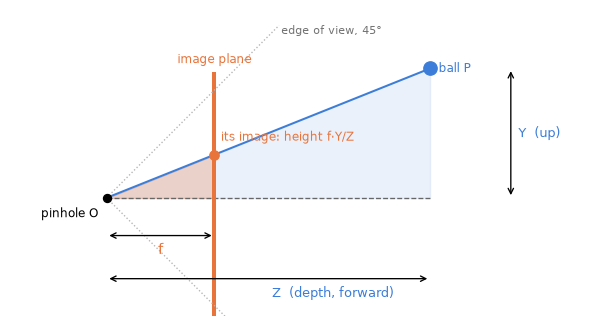

In [3]:
# An illustrative sketch (not to scale): the camera seen from the side.
f, Zp, Yp = 1.0, 3.0, 1.2
fig, ax = plt.subplots(figsize=(8.6, 3.5))
ax.plot([0, Zp], [0, Yp], color="#3b7dd8", lw=1.5)                                   # the ray
ax.plot([0, Zp], [0, 0], color="0.4", lw=1, ls="--")                                 # the optical axis
ax.plot([f, f], [-1.15, 1.15], color="#e8743b", lw=3)                                # the image plane
for s in (1, -1):
    ax.plot([0, 1.6], [0, 1.6 * s], color="0.7", lw=1, ls=":")                        # the 45° edge rays
ax.text(1.62, 1.55, "edge of view, 45°", fontsize=8, color="0.45", va="center")
ax.fill([0, Zp, Zp], [0, 0, Yp], color="#3b7dd8", alpha=0.10)
ax.fill([0, f, f], [0, 0, f * Yp / Zp], color="#e8743b", alpha=0.25)
ax.plot(0, 0, "ko", ms=6); ax.text(-0.08, -0.18, "pinhole O", ha="right", fontsize=9)
ax.plot(Zp, Yp, "o", color="#3b7dd8", ms=10); ax.text(Zp + 0.08, Yp, "ball P", fontsize=9, va="center", color="#3b7dd8")
ax.plot(f, f * Yp / Zp, "o", color="#e8743b", ms=7)
ax.text(f + 0.06, f * Yp / Zp + 0.13, "its image: height f·Y/Z", fontsize=9, color="#e8743b")
ax.annotate("", xy=(f, -0.35), xytext=(0, -0.35), arrowprops=dict(arrowstyle="<->", lw=1))
ax.text(f / 2, -0.52, "f", ha="center", fontsize=11, color="#e8743b")
ax.annotate("", xy=(Zp, -0.75), xytext=(0, -0.75), arrowprops=dict(arrowstyle="<->", lw=1))
ax.text(2.1, -0.92, "Z  (depth, forward)", ha="center", fontsize=10, color="#3b7dd8")
ax.annotate("", xy=(Zp + 0.75, Yp), xytext=(Zp + 0.75, 0), arrowprops=dict(arrowstyle="<->", lw=1))
ax.text(Zp + 0.82, Yp / 2, "Y  (up)", fontsize=10, color="#3b7dd8", va="center")
ax.text(f, 1.25, "image plane", ha="center", fontsize=9, color="#e8743b")
ax.set_xlim(-0.9, 4.6); ax.set_ylim(-1.1, 1.75); ax.set_aspect("equal"); ax.axis("off")
fig.tight_layout(); plt.show()

A pinhole camera lets through only the ray from each point that passes
the pinhole ${O}$. Graphics puts the image plane *in front of* the
pinhole at distance ${\color{#e8743b}{f}}$, so the picture is not upside
down. The drawing is a sketch, seen from the side: forward is to the
right, up is up.

------------------------------------------------------------------------

## Similar triangles: image = f · Y / Z

**Step 1 — similar triangles.** The pale blue triangle (O, the axis at
depth ${\color{#3b7dd8}{Z}}$, the ball) and the orange one (O, the axis
at ${\color{#e8743b}{f}}$, the image) share the angle at O, so their
sides are in proportion:

$$\frac{\text{image height}}{{\color{#e8743b}{f}}} = \frac{{\color{#3b7dd8}{Y}}}{{\color{#3b7dd8}{Z}}}
\quad\Longrightarrow\quad \text{image height} = {\color{#e8743b}{f}}\,\frac{{\color{#3b7dd8}{Y}}}{{\color{#3b7dd8}{Z}}},
$$

Seen from above instead of from the side, the same triangles give the
horizontal position:

$$\text{image across} = {\color{#e8743b}{f}}\,\frac{{\color{#3b7dd8}{X}}}{{\color{#3b7dd8}{Z}}} .$$

**Step 2 — the division is the whole camera.** Everything a camera does
to geometry is *divide by depth*. Twice as far away → half the size in
the picture; a ball twice as far in the same direction lands on the
**same** pixel.

------------------------------------------------------------------------

## From two angles to a pixel

**Step 1 — the direction as a point.** A ball at distance $D$, azimuth
${\color{#3b7dd8}{a}}$, elevation ${\color{#3b7dd8}{e}}$ sits, in the
camera’s frame (right, up, forward), at

$${\color{#3b7dd8}{X}} = -D\cos{\color{#3b7dd8}{e}}\sin{\color{#3b7dd8}{a}},\qquad
{\color{#3b7dd8}{Y}} = D\sin{\color{#3b7dd8}{e}},\qquad
{\color{#3b7dd8}{Z}} = D\cos{\color{#3b7dd8}{e}}\cos{\color{#3b7dd8}{a}} .$$

The minus sign on ${\color{#3b7dd8}{X}}$: azimuth counts to the robot’s
**left**, the picture’s x axis points to its **right**.

**Step 2 — divide by depth** (Step 1 of the last slide, with
${\color{#e8743b}{f}} = 1$), and let ${\color{#e8743b}{v}}$ count
**down**, as picture rows do. $D$ cancels:

$${\color{#e8743b}{u}} = \frac{{\color{#3b7dd8}{X}}}{{\color{#3b7dd8}{Z}}} = -\tan{\color{#3b7dd8}{a}},
\qquad
{\color{#e8743b}{v}} = -\frac{{\color{#3b7dd8}{Y}}}{{\color{#3b7dd8}{Z}}} = -\frac{\tan{\color{#3b7dd8}{e}}}{\cos{\color{#3b7dd8}{a}}} .$$

With ${\color{#e8743b}{f}} = 1$ the edge of a 90° view is at
$\tan 45° = 1$, so
${\color{#e8743b}{u}}, {\color{#e8743b}{v}} \in [-1, 1]$ cover the
picture exactly. Note ${\color{#e8743b}{v}}$ is **not** just
$-\tan{\color{#3b7dd8}{e}}$: a ball off to the side is further away in
depth, so the same elevation appears smaller.

------------------------------------------------------------------------

## Angles to pixels: the last step

**Step 3 — to pixels.** A 64-pixel picture spreads $[-1, 1]$ over 64
columns whose centres are $0, 1, \dots, 63$:

$$\text{column} = 32\,{\color{#e8743b}{u}} + 31.5, \qquad \text{row} = 32\,{\color{#e8743b}{v}} + 31.5 ,$$

i.e. a focal length of ${\color{#e8743b}{f}} = 32$ **pixels**. This is
`vision.uv_of` line by line:

``` python
def uv_of(az, el):
    f = np.cos(el) * np.cos(az)                                        # Z / D
    return np.stack([-np.cos(el) * np.sin(az) / f, -np.sin(el) / f], -1)   # X/Z, -Y/Z
```

------------------------------------------------------------------------

## Checking the formula against the renderer

az  +0° el  +0°:  formula column  31.5 row  31.5   red pixels' centre column  31.5 row  31.0   (row if v were -tan e:  31.5)
az +34° el -17°:  formula column   9.6 row  43.5   red pixels' centre column   8.9 row  43.3   (row if v were -tan e:  41.4)
az -29° el +14°:  formula column  49.0 row  22.2   red pixels' centre column  49.6 row  21.5   (row if v were -tan e:  23.3)
az +40° el +20°:  formula column   4.5 row  16.2   red pixels' centre column   3.1 row  14.9   (row if v were -tan e:  19.8)
pixels per 10° of azimuth: 5.6 near the centre, 9.6 between 35° and 45°

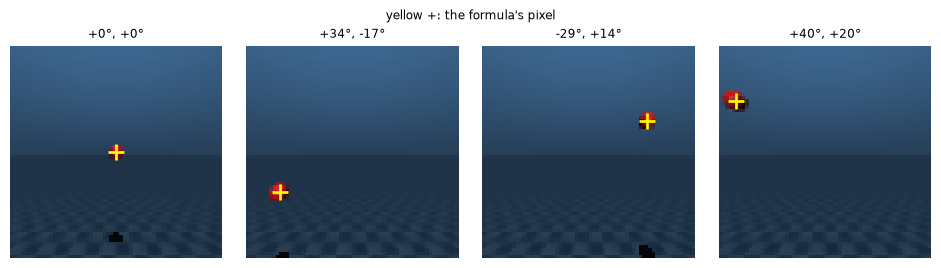

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(10, 2.8))
with _new_renderer(model, 64, 64) as r:
    for ax, (az, el) in zip(axes, ((0.0, 0.0), (0.6, -0.3), (-0.5, 0.25), (0.7, 0.35))):
        vision.place_ball(model, data, 0, az, el, 1.6); mujoco.mj_forward(model, data)
        r.update_scene(data, camera="head"); img = r.render().copy()
        red = (img[..., 0] > 120) & (img[..., 1] < 80) & (img[..., 2] < 80)    # the ball's pixels
        rows, cols = np.nonzero(red)
        u, v = vision.uv_of(az, el)
        print(f"az {math.degrees(az):+3.0f}° el {math.degrees(el):+3.0f}°:  formula column {32*u+31.5:5.1f} row {32*v+31.5:5.1f}"
              f"   red pixels' centre column {cols.mean():5.1f} row {rows.mean():5.1f}"
              f"   (row if v were -tan e: {32*-math.tan(el)+31.5:5.1f})")
        ax.imshow(img); ax.plot(32 * u + 31.5, 32 * v + 31.5, "+", color="yellow", ms=12, mew=2)
        ax.set_title(f"{math.degrees(az):+.0f}°, {math.degrees(el):+.0f}°", fontsize=9); ax.axis("off")
print(f"pixels per 10° of azimuth: {32*math.tan(math.radians(10)):.1f} near the centre, "
      f"{32*(1 - math.tan(math.radians(35))):.1f} between 35° and 45°")
fig.suptitle("yellow +: the formula's pixel", fontsize=9); fig.tight_layout(); plt.show()

The formula lands within 1.5 pixels of the red blob’s centre every time
(a sphere seen off-axis projects to a slightly stretched blob, so the
blob’s centre is not exactly the projection of the ball’s centre). At
40° left and 20° up the plain $-\tan e$ would put the ball at row 19.8
against a measured 14.9 — five rows off; the $1/\cos a$ is real.

Because of the $\tan$, **pixels are not evenly spaced in angle**: 10°
near the middle is about 5.6 pixels, 10° near the edge about 9.6. Week
15 uses the same formula backwards (`angles_of_uv`) to turn a pixel into
a direction.

------------------------------------------------------------------------

## Labels for free

The whole difficulty of supervised learning on a real robot is *labels*:
someone has to say where the ball is in ten thousand photographs.

In simulation we **put** it there.

In [5]:
t0 = time.time()
X, Y = vision.render_dataset(model, 4000, seed=0)
Xtest, Ytest = vision.render_dataset(model, 500, seed=1000)
print(f"images {X.shape} {X.dtype}, labels {Y.shape}   ({time.time() - t0:.1f} s)")
print(f"first label: azimuth {math.degrees(Y[0, 0, 0]):+.1f}°, elevation {math.degrees(Y[0, 0, 1]):+.1f}°")

images (4000, 3, 64, 64) uint8, labels (4000, 1, 2)   (5.3 s)
first label: azimuth +11.0°, elevation -18.9°

Each picture is 64 × 64 × 3 = 12,288 numbers. Each label is 2. Rendering
the lot takes seconds; on a real robot the same dataset is a week of
work.

`render_dataset` places the ball at a random azimuth in ±40°, elevation
in −34°…+23° and distance 0.8–2.5 m, renders from `camera="head"`, and
records the two angles it chose.

------------------------------------------------------------------------

## 4000 of them, at the size the network sees

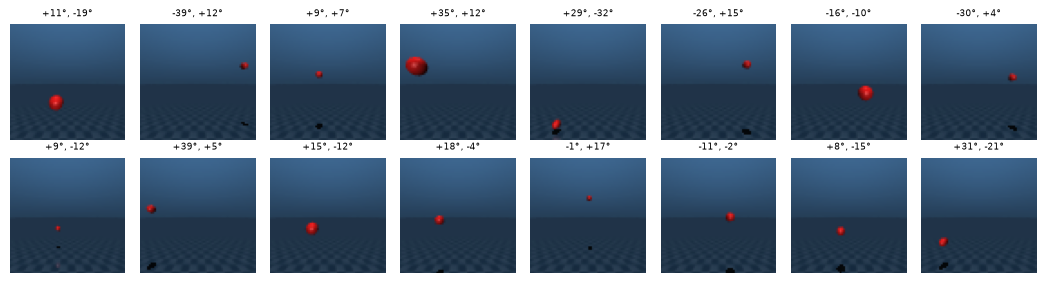

In [6]:
fig, axes = plt.subplots(2, 8, figsize=(11, 3))
for ax, img, y in zip(axes.flat, X[:16], Y[:16]):
    ax.imshow(img.transpose(1, 2, 0)); ax.axis("off")
    ax.set_title(f"{math.degrees(y[0, 0]):+.0f}°, {math.degrees(y[0, 1]):+.0f}°", fontsize=7)
fig.tight_layout(); plt.show()

The ball is a few pixels across when it is far away. A network does not
need the picture to be pretty; it needs it to be *consistent*.

------------------------------------------------------------------------

## Why not an ordinary network?

A fully-connected layer from 12,288 pixels to 64 hidden units has
**786,000** weights, and each one is tied to *one pixel*. A ball seen at
the left edge and the same ball at the right edge share nothing: the
network would have to learn “red blob” separately at every position.

A **convolution** slides one small filter over every position of the
picture:

$$\text{out}[i,j] = \sum_{c}\sum_{m,n} {\color{#2a9d5c}{w}}[c,m,n]\;\text{in}[c,\,i+m,\,j+n] + {\color{#2a9d5c}{b}}$$

- $\text{in}[c, i, j]$ — the input: channel $c$ (red, green, blue for a
  picture), row $i$, column $j$
- ${\color{#2a9d5c}{w}}[c, m, n]$ — the filter: one small grid of
  weights per input channel; $m, n$ run over its rows and columns (0, 1,
  2 for 3 × 3)
- ${\color{#2a9d5c}{b}}$ — one bias number added everywhere
- $\text{out}[i, j]$ — one number per position: *how well does the patch
  whose top-left corner is $(i, j)$ match the filter?*

------------------------------------------------------------------------

## What sliding one filter buys

A 3 × 3 filter on a 3-channel picture is $3 \cdot 3 \cdot 3 = 27$
weights and one bias — 28 numbers, against 786,432 for the
fully-connected layer. Three consequences:

- The **same** weights at every position: *weight sharing*. A red-blob
  detector learned once works anywhere.
- The output keeps the **layout**: cell $(i,j)$ is about that part of
  the image.
- A layer has many filters; each makes one output **channel**.

The next three slides do it by hand, in 1-D, then 2-D, then with stride.

------------------------------------------------------------------------

## Convolution by hand: one dimension

by hand: [ 1.  3.  0. -3. -1.]    torch conv1d: [ 1.  3.  0. -3. -1.]

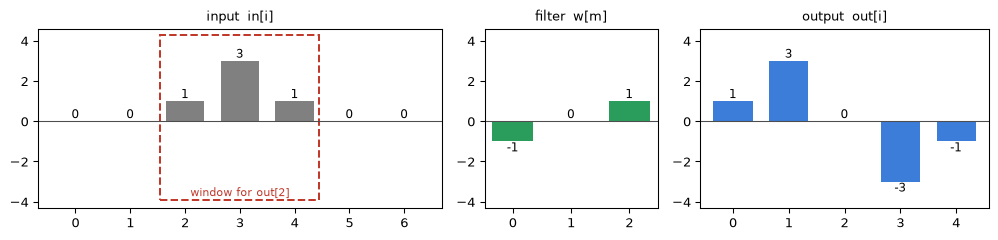

In [7]:
sig = np.array([0, 0, 1, 3, 1, 0, 0], float)          # a "bump" in a row of pixels
w1 = np.array([-1, 0, 1], float)                        # right minus left: an edge detector
out1 = np.array([sum(w1[m] * sig[i + m] for m in range(3)) for i in range(len(sig) - 2)])
ref = torch.nn.functional.conv1d(torch.tensor(sig)[None, None], torch.tensor(w1)[None, None]).numpy().ravel()
print("by hand:", out1, "   torch conv1d:", ref)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.6), gridspec_kw=dict(width_ratios=[7, 3, 5]))
for ax, vals, name, col in ((axes[0], sig, "input  in[i]", "0.5"), (axes[1], w1, "filter  w[m]", "#2a9d5c"),
                            (axes[2], out1, "output  out[i]", "#3b7dd8")):
    ax.bar(range(len(vals)), vals, color=col, width=0.7)
    for k, v in enumerate(vals):
        ax.text(k, v + (0.15 if v >= 0 else -0.5), f"{v:g}", ha="center", fontsize=9)
    ax.axhline(0, color="0.3", lw=0.8); ax.set_title(name, fontsize=10); ax.set_xticks(range(len(vals)))
    ax.set_ylim(-4.3, 4.6)
axes[0].add_patch(plt.Rectangle((1.55, -3.9), 3.0 - 0.1, 8.2, fill=False, ec="#c0392b", lw=1.5, ls="--"))
axes[0].text(3.0, -3.85, "window for out[2]", ha="center", fontsize=8, color="#c0392b", va="bottom")
fig.tight_layout(); plt.show()

The dashed box is the window that produces $\text{out}[2]$: inputs 2, 3,
4. Slide it one place right and it produces $\text{out}[3]$.

------------------------------------------------------------------------

## The same, written out

Write it out for every output position
($\text{out}[i] = \sum_m {\color{#2a9d5c}{w}}[m]\,\text{in}[i+m]$, no
bias):

| $i$ | window $\text{in}[i..i{+}2]$ | $-1\cdot\text{in}[i] + 0\cdot\text{in}[i{+}1] + 1\cdot\text{in}[i{+}2]$ | out |
|------------------|------------------|------------------|------------------|
| 0 | 0, 0, 1 | $0 + 0 + 1$ | **1** |
| 1 | 0, 1, 3 | $0 + 0 + 3$ | **3** |
| 2 | 1, 3, 1 | $-1 + 0 + 1$ | **0** |
| 3 | 3, 1, 0 | $-3 + 0 + 0$ | **−3** |
| 4 | 1, 0, 0 | $-1 + 0 + 0$ | **−1** |

The filter answers “is it getting brighter to the right?”: positive on
the rising side of the bump, zero on its peak, negative on the falling
side. 7 inputs and a 3-wide filter give $7 - 3 + 1 = 5$ outputs. PyTorch
computes exactly this — no flipping of the filter (mathematicians’
convolution flips it; deep learning keeps the old name for the unflipped
version).

------------------------------------------------------------------------

## Two dimensions, and colour channels

hand == torch conv2d: True    out[1, 1] = 13.0

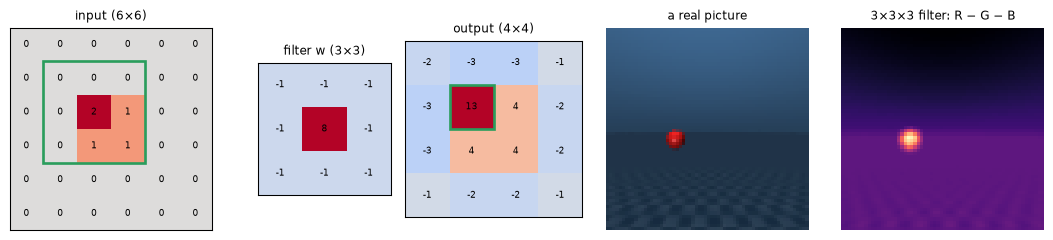

In [8]:
grid = np.zeros((6, 6)); grid[2:4, 2:4] = 1.0; grid[2, 2] = 2.0     # a small bright blob
w2 = -np.ones((3, 3)); w2[1, 1] = 8.0                                 # centre minus surround
out2 = np.array([[np.sum(w2 * grid[i:i + 3, j:j + 3]) for j in range(4)] for i in range(4)])
ref2 = torch.nn.functional.conv2d(torch.tensor(grid)[None, None], torch.tensor(w2)[None, None]).numpy()[0, 0]
print("hand == torch conv2d:", np.allclose(out2, ref2), "   out[1, 1] =", out2[1, 1])

vision.place_ball(model, data, 0, 0.3, -0.1, 1.2); mujoco.mj_forward(model, data)
with _new_renderer(model, 64, 64) as r:
    r.update_scene(data, camera="head"); pic = r.render().copy()
wred = torch.zeros(1, 3, 3, 3); wred[0, 0] = 1 / 9; wred[0, 1] = -1 / 9; wred[0, 2] = -1 / 9   # red minus green minus blue
redness = torch.nn.functional.conv2d(vision.as_tensor(pic.transpose(2, 0, 1)[None]), wred)[0, 0].numpy()

fig, axes = plt.subplots(1, 5, figsize=(11.5, 2.6), gridspec_kw=dict(width_ratios=[6, 3, 4, 5, 5]))
for ax, a, name in ((axes[0], grid, "input (6×6)"), (axes[1], w2, "filter w (3×3)"), (axes[2], out2, "output (4×4)")):
    ax.imshow(a, cmap="coolwarm", vmin=-np.abs(a).max(), vmax=np.abs(a).max())
    for (i, j), v in np.ndenumerate(a):
        ax.text(j, i, f"{v:g}", ha="center", va="center", fontsize=7)
    ax.set_title(name, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
axes[0].add_patch(plt.Rectangle((0.5, 0.5), 3, 3, fill=False, ec="#2a9d5c", lw=2))
axes[2].add_patch(plt.Rectangle((0.5, 0.5), 1, 1, fill=False, ec="#2a9d5c", lw=2))
axes[3].imshow(pic); axes[3].set_title("a real picture", fontsize=9); axes[3].axis("off")
axes[4].imshow(redness, cmap="magma"); axes[4].set_title("3×3×3 filter: R − G − B", fontsize=9); axes[4].axis("off")
fig.tight_layout(); plt.show()

**One entry by hand.** $\text{out}[1,1]$ uses the green-boxed window,
rows 1–3 and columns 1–3 of the input. The centre (input $[2,2] = 2$) is
weighted $+8$; the eight neighbours, of which three are 1 and five are
0, are weighted $-1$: $8 \cdot 2 - (1 + 1 + 1) = 13$. The filter says
“bright here, dark around”: it is largest where the blob is.

**Colour.** A picture has three channels, so a filter has three 3 × 3
grids, one per channel, and the $\sum_c$ adds the three results. The
right-hand panel is a hand-made filter, $+\tfrac19$ on red and
$-\tfrac19$ on green and blue: it lights up where the ball is and
nowhere else. BallNet’s filters are not hand-made; training picks their
numbers.

------------------------------------------------------------------------

## Stride and padding: 64 → 32 → 16 → 8

Two more knobs. **Stride** $s$: move the window $s$ pixels at a time, so
only every $s$-th output is kept. **Padding** $p$: add $p$ rows and
columns of zeros around the input, so the window can sit on the edge.

**Step 1 — count the window positions.** An input of $N$ pixels, padded
to $N + 2p$, holds a $k$-wide window at starting positions
$0, s, 2s, \dots$ up to $N + 2p - k$. The number of positions is

$$N_{\text{out}} = \left\lfloor \frac{N + 2p - k}{s} \right\rfloor + 1 .$$

(The 1-D example: $N=7, p=0, k=3, s=1$ gives $4 + 1 = 5$.)

**Step 2 — BallNet’s three layers**,
$(k, s, p) = (5, 2, 2), (3, 2, 1), (3, 2, 1)$:

$$\left\lfloor\tfrac{64 + 4 - 5}{2}\right\rfloor + 1 = 31 + 1 = 32,\qquad
\left\lfloor\tfrac{32 + 2 - 3}{2}\right\rfloor + 1 = 15 + 1 = 16,\qquad
\left\lfloor\tfrac{16 + 2 - 3}{2}\right\rfloor + 1 = 7 + 1 = 8 .$$

**Step 3 — how much picture one cell sees** (its *receptive field*).
Each layer adds $(k - 1)$ times the product of the strides before it:
$5$, then $5 + 2 \cdot 2 = 9$, then $9 + 2 \cdot 4 = 17$ pixels.

------------------------------------------------------------------------

## BallNet, layer by layer

In [9]:
x = torch.zeros(1, 3, 64, 64)
for layer in vision.BallNet().net:
    x = layer(x)
    if not isinstance(layer, torch.nn.ReLU):
        print(f"{type(layer).__name__:8s} -> {str(tuple(x.shape[1:])):14s} {sum(p.numel() for p in layer.parameters()):8,d} numbers")
xin = torch.rand(1, 3, 64, 64, requires_grad=True)
vision.BallNet().net[:6](xin)[0, :, 4, 4].sum().backward()          # which pixels can move cell (4, 4)?
rows, cols = np.nonzero(xin.grad.abs().sum(1)[0].numpy() > 0)
print(f"cell (4, 4) of the last 8x8 grid depends on rows {rows.min()}-{rows.max()}, columns {cols.min()}-{cols.max()}: "
      f"{rows.max() - rows.min() + 1} x {cols.max() - cols.min() + 1} pixels")

Conv2d   -> (16, 32, 32)      1,216 numbers
Conv2d   -> (32, 16, 16)      4,640 numbers
Conv2d   -> (32, 8, 8)        9,248 numbers
Flatten  -> (2048,)               0 numbers
Linear   -> (64,)           131,136 numbers
Linear   -> (2,)                130 numbers
cell (4, 4) of the last 8x8 grid depends on rows 24-40, columns 24-40: 17 x 17 pixels

A convolution’s count is
$k \cdot k \cdot C_{\text{in}} \cdot C_{\text{out}} + C_{\text{out}}$:
the first layer is $5 \cdot 5 \cdot 3 \cdot 16 + 16 = 1{,}216$. The
measured receptive field is the 17 × 17 predicted by Step 3. And the
three convolutions together are only 15,104 numbers: **nine-tenths of
BallNet is the first linear layer** (131,136), which reads all 2,048
outputs at once.

------------------------------------------------------------------------

## BallNet

In [10]:
def fresh(seed=0):
    torch.manual_seed(seed)          # the same starting weights every time, as look.py
    return vision.BallNet()

net = fresh()
print(net)
print(f"\nparameters: {sum(p.numel() for p in net.parameters()):,}")

BallNet(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2048, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=2, bias=True)
  )
)

parameters: 146,370

Three convolutions (16, 32, 32 channels, each stride 2), flatten the 32
× 8 × 8 result, then two linear layers down to **two numbers**. It
regresses the angles directly, with squared error — the same loss as
week 13’s behaviour cloning, pointed at a different question.

146,370 numbers, every one of them a ${\color{#2a9d5c}{w}}$ or a
${\color{#2a9d5c}{b}}$ that training will choose. Next: what “choose”
means.

------------------------------------------------------------------------

## The loss: squared error, written out

For a batch of $B$ pictures, the network’s answer $\hat y_{i}$ and the
truth $y_{i}$ are each two numbers (azimuth, elevation). The loss is the
average squared difference over all $2B$ numbers:

$${\color{#c0392b}{L}}(\theta) = \frac{1}{2B}\sum_{i=1}^{B}\;\sum_{j\in\{a,\,e\}} \big(\hat y_{ij}(\theta) - y_{ij}\big)^2$$

- $\theta$ — all 146,370 learned numbers (every ${\color{#2a9d5c}{w}}$
  and ${\color{#2a9d5c}{b}}$) together
- $\hat y_{ij}(\theta)$ — the network’s estimate of angle $j$ for
  picture $i$; it depends on $\theta$
- $y_{ij}$ — the label the simulator recorded
- unit: radians², because the angles are in radians

This is `((net(x) - y) ** 2).mean()` — `.mean()` divides by all $2B$
numbers. So $\sqrt{{\color{#c0392b}{L}}}$ is the **root-mean-square
error per angle**, and the training cell prints it in degrees.

------------------------------------------------------------------------

## Its slope, and one step downhill

**Why squared?** It is zero only when every estimate is exact, it
punishes a 10° miss a hundred times more than a 1° miss, and its slope
is simple:

$$\frac{\partial {\color{#c0392b}{L}}}{\partial \hat y_{ij}} = \frac{1}{2B}\cdot 2\,(\hat y_{ij} - y_{ij}) = \frac{\hat y_{ij} - y_{ij}}{B} .$$

The slope of the loss with respect to *one answer* is just that answer’s
error. `loss.backward()` carries it back through every layer by the
chain rule, to the slope with respect to every weight,
$\partial{\color{#c0392b}{L}}/\partial\theta$.

**The smallest possible network: one weight.**
$\hat y = {\color{#2a9d5c}{w}}\,x$, one example $x = 2$, $y = 1$,
starting from ${\color{#2a9d5c}{w}} = 0$, learning rate
${\color{#c0392b}{\eta}} = 0.1$:

| step | ${\color{#2a9d5c}{w}}$ | $\hat y = {\color{#2a9d5c}{w}}x$ | ${\color{#c0392b}{L}} = (\hat y - y)^2$ | slope $\;2(\hat y - y)\,x$ | new ${\color{#2a9d5c}{w}} = {\color{#2a9d5c}{w}} - {\color{#c0392b}{\eta}}\cdot$slope |
|------------|------------|------------|------------|------------|------------|
| 0 | 0 | 0 | 1 | $2(0-1)\cdot 2 = -4$ | $0 + 0.4 = 0.4$ |
| 1 | 0.4 | 0.8 | 0.04 | $2(0.8-1)\cdot 2 = -0.8$ | $0.4 + 0.08 = 0.48$ |
| 2 | 0.48 | 0.96 | 0.0016 | … |  |

The slope is negative, so stepping **against** it raises
${\color{#2a9d5c}{w}}$ — toward 0.5, where $\hat y = y$. Each step here
cuts the error by a factor of 5.

------------------------------------------------------------------------

## One step on BallNet

**The same step on BallNet**, all 146,370 numbers at once:
$\theta \leftarrow \theta - {\color{#c0392b}{\eta}}\,\partial{\color{#c0392b}{L}}/\partial\theta$.

In [11]:
probe = fresh()                                          # untrained; reseeds, so `net` is unaffected
xb, yb = vision.as_tensor(X[:64]), torch.as_tensor(Y[:64, 0])
L0 = ((probe(xb) - yb) ** 2).mean(); L0.backward()
g2 = sum(float((p.grad ** 2).sum()) for p in probe.parameters())
eta = 0.1
with torch.no_grad():
    for p in probe.parameters():
        p -= eta * p.grad                                 # the gradient step, written out
    L1 = ((probe(xb) - yb) ** 2).mean()
print(f"loss before {L0.item():.4f} rad² ({math.degrees(math.sqrt(L0.item())):.1f}° rms)   "
      f"after one step {L1.item():.4f} ({math.degrees(math.sqrt(L1.item())):.1f}° rms)")
print(f"change {L1.item() - L0.item():+.4f};  first-order prediction  -eta x |slope|² = {-eta * g2:+.4f}")

loss before 0.1430 rad² (21.7° rms)   after one step 0.1392 (21.4° rms)
change -0.0039;  first-order prediction  -eta x |slope|² = -0.0041

One step lowers the loss by almost exactly what the slope predicts
(${\color{#c0392b}{\Delta L}} \approx -{\color{#c0392b}{\eta}}\,\lVert\partial{\color{#c0392b}{L}}/\partial\theta\rVert^2$),
and by very little: training takes 630 of them (10 passes over 4,000
pictures in batches of 64). The training cell uses **Adam** instead of
the plain step: the same slope, but each number’s step is divided by a
running average of the size of its own slopes, so every weight moves at
a sensible rate without hand-tuning ${\color{#c0392b}{\eta}}$ for each.

------------------------------------------------------------------------

## Training

In [12]:
def train(net, X, Y, epochs=10):
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    Xt, Yt = vision.as_tensor(X), torch.as_tensor(Y[:, 0])
    curve = []
    for epoch in range(epochs):
        perm = torch.randperm(len(Xt)); total = 0.0
        for i in range(0, len(Xt), 64):
            b = perm[i:i + 64]
            loss = ((net(Xt[b]) - Yt[b]) ** 2).mean()        # squared error, radians²
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item() * len(b)
        curve.append(math.degrees(math.sqrt(total / len(Xt))))
    return curve

def error_deg(net, images, labels):
    with torch.no_grad():
        p = net(vision.as_tensor(images)).numpy()
    return np.degrees(np.linalg.norm(p - labels[:, 0], axis=1))

t0 = time.time()
curve = train(net, X, Y)
err = error_deg(net, Xtest, Ytest)
guess = np.degrees(np.linalg.norm(Ytest[:, 0] - Y[:, 0].mean(0), axis=1)).mean()
print(f"{time.time() - t0:.0f} s; training error by epoch (deg, rms per angle): " + " ".join(f"{c:.1f}" for c in curve))
print(f"test: mean error {err.mean():.1f}°, {100 * np.mean(err < 5):.0f}% within 5°   "
      f"(always guessing the average: {guess:.1f}°)")

7 s; training error by epoch (deg, rms per angle): 16.2 7.7 3.9 2.4 1.8 1.5 1.7 1.8 1.2 1.1
test: mean error 1.0°, 100% within 5°   (always guessing the average: 26.0°)

**Reading the numbers.** The first line is $\sqrt{{\color{#c0392b}{L}}}$
in degrees, averaged over each pass: 16° in the first pass, 1–2° by the
fifth. The test error is measured differently — the straight-line
distance between the true and the estimated (azimuth, elevation), on 500
pictures never trained on — and it is about **one degree**, against 26°
for a “network” that always answers the average direction. From a
network the size of a thumbnail. That is the easy half of the week.

------------------------------------------------------------------------

## Where it is right, and where it is not

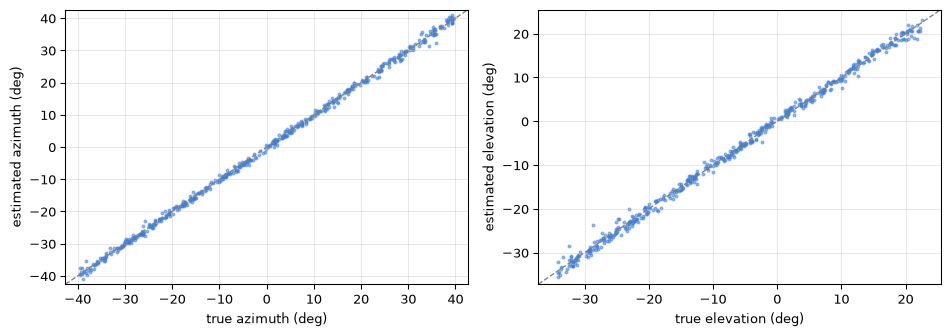

In [13]:
with torch.no_grad():
    pred = net(vision.as_tensor(Xtest)).numpy()
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, k, name in ((a0, 0, "azimuth"), (a1, 1, "elevation")):
    t, p = np.degrees(Ytest[:, 0, k]), np.degrees(pred[:, k])
    ax.scatter(t, p, s=4, alpha=0.5, color="#3b7dd8")
    lo, hi = t.min() - 3, t.max() + 3
    ax.plot([lo, hi], [lo, hi], color="0.5", lw=1, ls="--")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel(f"true {name} (deg)"); ax.set_ylabel(f"estimated {name} (deg)"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

Every point on the diagonal is a perfect estimate. Nobody told the
network what a ball is, or that red matters: it had to find *something*
in the pixels that predicts the two angles. The next slide asks whether
what it found was *ball*.

------------------------------------------------------------------------

## A different world

Same network, same camera, same scene. Two changes it was never shown: a
**blue** ball, and the lights at **30%**.

In [14]:
Xblue, Yblue = vision.render_dataset(model, 500, seed=1001, colour=lambda r: (0.1, 0.2, 0.9))
Xdim, Ydim = vision.render_dataset(model, 500, seed=1002, light=lambda r: 0.3)
rows = [("red ball (as trained)", Xtest, Ytest), ("blue ball", Xblue, Yblue), ("red ball, dim room", Xdim, Ydim)]
print(f"{'test set':22s} {'mean error':>11} {'within 5°':>10}")
for name, xi, yi in rows:
    e = error_deg(net, xi, yi)
    print(f"{name:22s} {e.mean():9.1f}°  {100 * np.mean(e < 5):8.0f}%")
print(f"{'always guess the mean':22s} {guess:9.1f}°")

test set                mean error  within 5°
red ball (as trained)        1.0°       100%
blue ball                   27.8°         2%
red ball, dim room          15.2°         1%
always guess the mean       26.0°

On the blue ball it is **worse than guessing the average**; in the dim
room fifteen times worse than on the pictures it knows. Whatever it
found in the pixels, it was not *ball*: it was closer to *red, lit like
this*.

------------------------------------------------------------------------

## What it sees, what it says

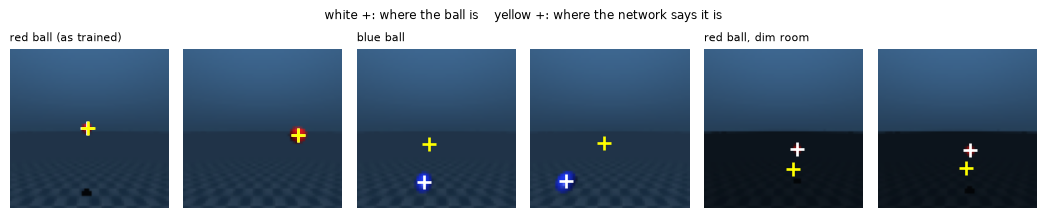

In [15]:
fig, axes = plt.subplots(1, 6, figsize=(11, 2.3))
for col, (name, xi, yi) in enumerate(rows):
    for k in range(2):
        ax = axes[2 * col + k]; img = xi[k]
        with torch.no_grad():
            p = net(vision.as_tensor(img[None])).numpy()[0]
        ax.imshow(img.transpose(1, 2, 0)); ax.axis("off")
        for (a, e), c in ((yi[k, 0], "w"), (p, "yellow")):
            u, v = vision.uv_of(a, e)
            ax.plot((u + 1) * 32 - 0.5, (v + 1) * 32 - 0.5, "+", color=c, ms=10, mew=2)
        ax.set_title(name if k == 0 else "", fontsize=8, loc="left")
fig.suptitle("white +: where the ball is    yellow +: where the network says it is", fontsize=9)
fig.tight_layout(); plt.show()

On the pictures it knows, the two crosses coincide. On the others the
yellow cross wanders: the network is not *uncertain*, it is
**confidently wrong**. Nothing in its output says “I have never seen
this before”.

------------------------------------------------------------------------

## This is the sim-to-real gap for eyes

A camera network trained in simulation meets a real camera and sees:
other colours, other lights, textures, lens blur, noise, motion blur, a
cable in the way. Every one of those is a “blue ball”.

**Domain randomisation** — Tobin et al., 2017 — is the week-12 idea
again: if you cannot make the simulator match the world, make the
simulator **vary so much** that the world looks like one more sample.

In [16]:
t0 = time.time()
Xr, Yr = vision.render_dataset(model, 4000, seed=0,
                               colour=lambda r: r.uniform(0, 1, 3),     # any colour at all
                               light=lambda r: r.uniform(0.3, 1.0))     # any brightness from 30% up
net_r = fresh(); curve_r = train(net_r, Xr, Yr)
print(f"trained on randomised pictures in {time.time() - t0:.0f} s")
print(f"{'test set':22s} {'plain':>8} {'randomised':>11}")
for name, xi, yi in rows:
    print(f"{name:22s} {error_deg(net, xi, yi).mean():7.1f}°  {error_deg(net_r, xi, yi).mean():9.1f}°")

trained on randomised pictures in 11 s
test set                  plain  randomised
red ball (as trained)      1.0°        4.4°
blue ball                 27.8°        9.4°
red ball, dim room        15.2°        4.2°

------------------------------------------------------------------------

## The price, and what it bought

| trained on                       | red, as trained | blue ball | dim room |
|----------------------------------|-----------------|-----------|----------|
| red balls only                   | **1.0°**        | 27.8°     | 15.2°    |
| random colour                    | 4.1°            | **5.0°**  | 27.2°    |
| random light                     | 1.3°            | 28.7°     | **1.6°** |
| both                             | 4.4°            | 9.4°      | 4.2°     |
| both, 12,000 pictures, 20 epochs | 4.4°            | 6.0°      | 3.8°     |

Measured with `look.py --randomise` (4000 pictures, 10 epochs unless
stated). Three lessons, each visible in one column:

1.  **Randomisation fixes exactly what it randomises.** Random light
    cures the dim room and does nothing for the blue ball; random colour
    the reverse.
2.  **Robustness costs accuracy on the easy case** — 1.0° becomes 4.4°.
    The network now has to be right about more worlds with the same
    capacity.
3.  **More data buys back the hard cases, not the easy one.** Three
    times the pictures and twice the epochs: blue 9.4° → 6.0°, dim 4.2°
    → 3.8°, red still 4.4°.

------------------------------------------------------------------------

## Closing the loop

A direction is only useful if something acts on it. The simplest action:
turn the waist until the ball is in the middle of the picture.

$$\text{waist}_{k+1} = \text{waist}_k + {\color{#8e44ad}{g}}\;{\color{#3b7dd8}{\hat{a}_k}}$$

where ${\color{#3b7dd8}{\hat a_k}}$ is the network’s azimuth from the
picture taken at step $k$, ten times a second, and
${\color{#8e44ad}{g}}$ is the gain: how much of the estimated error to
turn by at once. (In code, $\text{waist}$ is the waist servo’s
*command*, `d.ctrl[waist]`; the servo then moves the joint.) This is
**visual servoing**: the error is measured in the image, and the camera
moves with the thing being controlled.

In [17]:
def servo(net, gain, az0=35.0, seconds=3.0):
    d = mujoco.MjData(model); mujoco.mj_resetDataKeyframe(model, d, 0); mujoco.mj_forward(model, d)
    vision.place_ball(model, d, 0, math.radians(az0), 0.0, 1.5); ball = d.mocap_pos[0].copy(); mujoco.mj_forward(model, d)
    act_q = [int(model.jnt_qposadr[model.actuator_trnid[a, 0]]) for a in range(model.nu)]
    wq = soc4180.joint_index(model, "waist_yaw"); act = act_q.index(wq)
    d.ctrl[:] = model.key_qpos[0][act_q]
    log = []
    with _new_renderer(model, 64, 64) as r:
        while d.time < seconds:
            r.update_scene(d, camera="head")
            with torch.no_grad():
                est = float(net(vision.as_tensor(r.render().transpose(2, 0, 1)[None]))[0, 0])
            d.ctrl[act] = float(np.clip(d.ctrl[act] + gain * est, *model.actuator_ctrlrange[act]))
            log.append((d.time, math.degrees(d.qpos[wq]), math.degrees(vision.ball_direction(model, d, 0)[0]), d.qpos[2]))
            for _ in range(50):
                d.mocap_pos[0] = ball; mujoco.mj_step(model, d)
    return np.array(log)

runs = {g: servo(net, g) for g in (0.3, 0.8, 1.5, 2.2)}
for g, log in runs.items():
    print(f"gain {g:3.1f}: final ball offset {log[-1, 2]:+6.1f}°, pelvis {log[-1, 3]:.2f} m"
          + ("   FELL" if log[:, 3].min() < 0.5 else ""))

gain 0.3: final ball offset   +1.0°, pelvis 0.79 m
gain 0.8: final ball offset   +1.1°, pelvis 0.79 m
gain 1.5: final ball offset   +0.7°, pelvis 0.79 m
gain 2.2: final ball offset  +62.4°, pelvis 0.13 m   FELL

------------------------------------------------------------------------

## Four gains, drawn

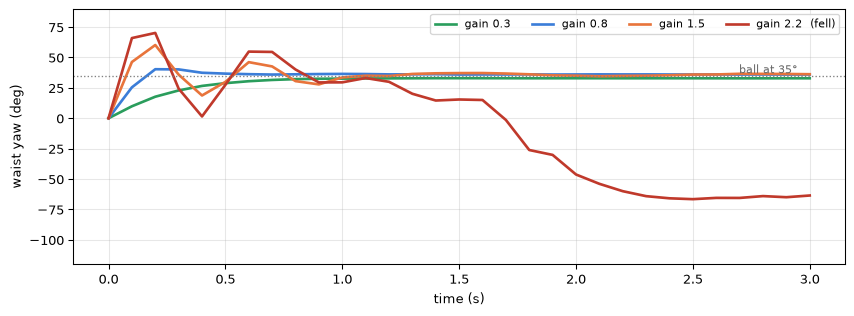

In [18]:
fig, ax = plt.subplots(figsize=(9, 3.4))
for (g, log), c in zip(runs.items(), ("#2a9d5c", "#3b7dd8", "#e8743b", "#c0392b")):
    ax.plot(log[:, 0], log[:, 1], color=c, lw=2, label=f"gain {g}" + ("  (fell)" if log[:, 3].min() < 0.5 else ""))
ax.axhline(35, color="0.5", ls=":", lw=1); ax.text(2.95, 37, "ball at 35°", ha="right", fontsize=8, color="0.4")
ax.set_ylim(-120, 90); ax.set_xlabel("time (s)"); ax.set_ylabel("waist yaw (deg)"); ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=4)
fig.tight_layout(); plt.show()

Week 5 in a new costume. Low gain is slow; 0.8 overshoots a little; 1.5
oscillates and settles; at 2.2 the torso swings so hard that **the robot
falls**, and once the ball leaves the picture the network’s output is
meaningless — it was never shown a picture with no ball in it.

The next three slides explain *why* these four gains behave as they do.

------------------------------------------------------------------------

## The loop as a discrete-time system

Name the quantities. The ball stays put at bearing
${\color{#3b7dd8}{\beta}}$ (35° left); the camera points at heading
${\color{#3b7dd8}{\psi_k}}$ when picture $k$ is taken. The ball’s
azimuth *in the picture* is the difference — and it is also the
**error**, zero when the ball is centred:

$${\color{#3b7dd8}{a_k}} = {\color{#3b7dd8}{\beta}} - {\color{#3b7dd8}{\psi_k}} .$$

Three idealisations, each tested on the next slides: **(A1)** the
estimate is perfect,
${\color{#3b7dd8}{\hat a_k}} = {\color{#3b7dd8}{a_k}}$; **(A2)** the
waist reaches its command before the next picture; **(A3)** the camera
turns exactly as much as the waist.

**Step 1 — the controller** (with A1–A3, the heading *is* the command):
${\color{#3b7dd8}{\psi_{k+1}}} = {\color{#3b7dd8}{\psi_k}} + {\color{#8e44ad}{g}}\,{\color{#3b7dd8}{a_k}}$.

**Step 2 — subtract both sides from ${\color{#3b7dd8}{\beta}}$:**
$${\color{#3b7dd8}{a_{k+1}}} = {\color{#3b7dd8}{\beta}} - {\color{#3b7dd8}{\psi_k}} - {\color{#8e44ad}{g}}\,{\color{#3b7dd8}{a_k}}
= {\color{#3b7dd8}{a_k}} - {\color{#8e44ad}{g}}\,{\color{#3b7dd8}{a_k}} = (1 - {\color{#8e44ad}{g}})\,{\color{#3b7dd8}{a_k}} .$$

**Step 3 — repeat $k$ times:**
${\color{#3b7dd8}{a_k}} = (1 - {\color{#8e44ad}{g}})^k\,{\color{#3b7dd8}{a_0}}$.
Every step multiplies the error by the same number,
$1 - {\color{#8e44ad}{g}}$.

------------------------------------------------------------------------

## What the gain does

$${\color{#3b7dd8}{a_k}} = (1 - {\color{#8e44ad}{g}})^k\,{\color{#3b7dd8}{a_0}}$$

| gain ${\color{#8e44ad}{g}}$ | $1 - {\color{#8e44ad}{g}}$ | the error, from 35° | behaviour |
|------------------|------------------|------------------|------------------|
| 0.3 | +0.7 | 35 → 24.5 → 17.1 → 12.0 | same sign, shrinking: **slow, no overshoot** |
| 1.0 | 0 | 35 → 0 | there in **one** step |
| 1.5 | −0.5 | 35 → −17.5 → +8.8 → −4.4 | sign flips: **overshoot**, oscillation that decays |
| 2.2 | −1.2 | 35 → −42 → +50 → −61 | flips and **grows**: unstable |

**The rule:** the error dies away if and only if
$|1 - {\color{#8e44ad}{g}}| < 1$, i.e. $0 < {\color{#8e44ad}{g}} < 2$;
no overshoot needs ${\color{#8e44ad}{g}} \le 1$. The model agrees with
the drawing *qualitatively*: 1.5 oscillates and settles, 2.2 does not.
Now test it quantitatively.

------------------------------------------------------------------------

## The model against the physics

 gain          model: first errors        physics, perfect estimate  overshoot  fell
  0.3   +35.0  +24.5  +17.1  +12.0     +35.0  +25.4  +17.0  +11.6       -0.0°    no
  0.8   +35.0   +7.0   +1.4   +0.3     +35.0  +16.6   -1.7   -3.4       -3.4°    no
  1.0   +35.0   +0.0   +0.0   +0.0     +35.0  +13.3   -7.7   -6.3       -7.7°    no
  1.5   +35.0  -17.5   +8.8   -4.4     +35.0   +5.9  -18.0  -11.1      -18.0°    no
  1.8   +35.0  -28.0  +22.4  -17.9     +35.0   +2.0  -21.6  -11.2      -21.6°   yes
  2.2   +35.0  -42.0  +50.4  -60.5     +35.0   -3.1  -23.7   -7.7      -23.7°   yes

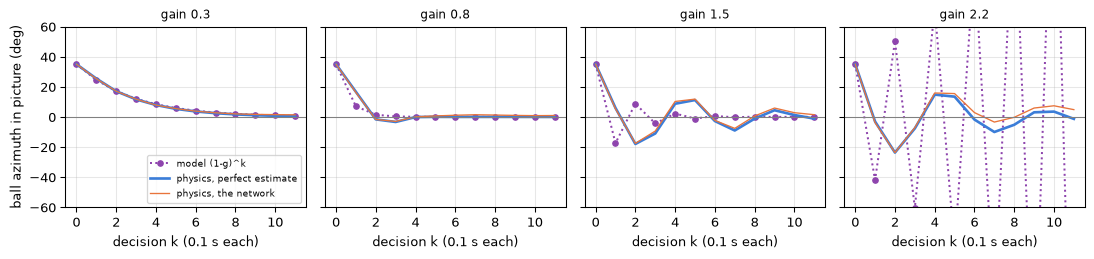

In [19]:
def servo_true(gain, az0=35.0, seconds=3.0):
    """The same loop with a PERFECT estimate: the simulator's true azimuth instead of the network's (A1 exact)."""
    d = mujoco.MjData(model); mujoco.mj_resetDataKeyframe(model, d, 0); mujoco.mj_forward(model, d)
    vision.place_ball(model, d, 0, math.radians(az0), 0.0, 1.5); ball = d.mocap_pos[0].copy(); mujoco.mj_forward(model, d)
    act_q = [int(model.jnt_qposadr[model.actuator_trnid[a, 0]]) for a in range(model.nu)]
    wq = soc4180.joint_index(model, "waist_yaw"); act = act_q.index(wq)
    d.ctrl[:] = model.key_qpos[0][act_q]
    log = []
    while d.time < seconds:
        a = vision.ball_direction(model, d, 0)[0]
        d.ctrl[act] = float(np.clip(d.ctrl[act] + gain * a, *model.actuator_ctrlrange[act]))
        log.append((d.time, math.degrees(a), d.qpos[2]))
        for _ in range(50):
            d.mocap_pos[0] = ball; mujoco.mj_step(model, d)
    return np.array(log)

print(f"{'gain':>5} {'model: first errors':>28} {'physics, perfect estimate':>32} {'overshoot':>10} {'fell':>5}")
perfect = {}
for g in (0.3, 0.8, 1.0, 1.5, 1.8, 2.2):
    perfect[g] = log = servo_true(g)
    model_err = 35 * (1 - g) ** np.arange(4)
    print(f"{g:5.1f}  " + " ".join(f"{v:+6.1f}" for v in model_err) + "    "
          + " ".join(f"{v:+6.1f}" for v in log[:4, 1]) + f"   {min(0.0, log[:, 1].min()):+8.1f}°  {'yes' if log[:, 2].min() < 0.5 else 'no':>4}")

fig, axes = plt.subplots(1, 4, figsize=(11.5, 2.8), sharey=True)
for ax, g in zip(axes, (0.3, 0.8, 1.5, 2.2)):
    k = np.arange(12)
    ax.plot(k, 35 * (1 - g) ** k, "o:", color="#8e44ad", ms=4, label="model (1-g)^k")
    ax.plot(k, perfect[g][:12, 1], "-", color="#3b7dd8", lw=2, label="physics, perfect estimate")
    ax.plot(k, runs[g][:12, 2], "-", color="#e8743b", lw=1, label="physics, the network")
    ax.axhline(0, color="0.5", lw=0.8); ax.set_ylim(-60, 60); ax.set_title(f"gain {g}", fontsize=9)
    ax.set_xlabel("decision k (0.1 s each)"); ax.set_xticks(range(0, 12, 2)); ax.grid(alpha=0.3)
axes[0].set_ylabel("ball azimuth in picture (deg)"); axes[0].legend(fontsize=7, loc="lower right")
fig.tight_layout(); plt.show()

How to read it. **Purple dots**: the model $35\,(1-g)^k$. **Blue**: the
simulated robot fed the *true* azimuth (A1 made exact). **Orange**: the
same robot fed the network’s estimate. In the table, *overshoot* is the
most negative azimuth reached, and *fell* means the pelvis dropped below
0.5 m within 3 s. Even gain 1.0, which the model says finishes in one
step, still has 13.3° left after that step and then overshoots by 7.7°.

------------------------------------------------------------------------

## Reading the comparison

- **Small gain: the model is right.** At 0.3 the model’s first steps are
  35 → 24.5 → 17.1; the simulated robot’s are within a degree of that.
- **Large gain: the robot runs about one decision behind the model.** At
  1.5 the model flips sign at $k = 1$ (−17.5); the robot reaches +5.9
  there and flips at $k = 2$ (−18.0), because the camera has turned less
  than commanded (measured below).
- **The network adds almost nothing.** The orange and blue lines lie on
  top of each other; the network’s only visible effect is its ~1° bias
  at the end, the test error from the training slide.
- **The body is what breaks the model.** At 0.8 the model predicts no
  overshoot, yet the robot overshoots by a few degrees; and with a
  *perfect* estimate the robot still falls at 1.8, below the model’s
  limit of 2. Assumptions A2 and A3 fail. The next slide measures why.

------------------------------------------------------------------------

## Why the body is not the model

In [20]:
act_q = [int(model.jnt_qposadr[model.actuator_trnid[a, 0]]) for a in range(model.nu)]
wq = soc4180.joint_index(model, "waist_yaw"); act = act_q.index(wq)
for step in (10, 28):
    d = mujoco.MjData(model); mujoco.mj_resetDataKeyframe(model, d, 0); mujoco.mj_forward(model, d)
    d.ctrl[:] = model.key_qpos[0][act_q]
    vision.place_ball(model, d, 0, math.radians(35), 0.0, 1.5); ball = d.mocap_pos[0].copy(); mujoco.mj_forward(model, d)
    a0 = math.degrees(vision.ball_direction(model, d, 0)[0])
    d.ctrl[act] = math.radians(step)                      # one command, as the loop sends it
    for _ in range(50):                                   # one decision period, 0.1 s
        d.mocap_pos[0] = ball; mujoco.mj_step(model, d)
    w, x, y, z = d.qpos[3:7]
    pelvis_yaw = math.degrees(math.atan2(2 * (w * z + x * y), 1 - 2 * (y * y + z * z)))
    turned = a0 - math.degrees(vision.ball_direction(model, d, 0)[0])
    print(f"command waist +{step}°: after 0.1 s waist {math.degrees(d.qpos[wq]):+5.1f}°, pelvis {pelvis_yaw:+5.1f}°, "
          f"camera turned {turned:+5.1f}° ({100 * turned / step:.0f}% of the command)")

command waist +10°: after 0.1 s waist  +9.1°, pelvis  -0.2°, camera turned  +9.2° (92% of the command)
command waist +28°: after 0.1 s waist +24.8°, pelvis  -7.1°, camera turned +18.4° (66% of the command)

A 10° command turns the camera almost the full 10° in 0.1 s: A2 and A3
hold. A 28° command (what gain 0.8 sends first, $0.8 \times 35$) moves
the waist most of the way — but the **pelvis twists the other way**: the
waist pushes the torso left and, by Newton’s third law, the legs right,
and the feet twist on the floor. The camera turns only about two-thirds
of the command, the next picture still sees a large error, and the next
command adds to a torso that is already swinging. That is the overshoot
at 0.8 — and at large gains the swing is what throws the robot over. **A
loop is only as good as the model of what it is moving** (week 5’s
lesson, seen through a camera).

------------------------------------------------------------------------

## What real robots do differently

| here | on a real robot |
|------------------------------------|------------------------------------|
| 64 × 64 pixels, rendered | 640 × 480 or more, from a lens, with noise and blur |
| one red ball | everything — people, doors, cups, cables |
| 4000 pictures, labelled free | pretrained encoders (ResNet, DINOv2, CLIP) trained on millions of images, then a small head trained on the robot’s own data |
| one frame, no memory | stacks of frames, or a recurrent state: motion is information |
| 10 Hz, no latency | 30–60 Hz, 30–100 ms from photon to action |
| colour randomisation | randomised textures, lights, camera poses, distractors, *and* real images |

The shape is the same: pixels → a small number of task-relevant
quantities → a controller. What changes is the size of the first arrow,
and that is why week 15 borrows an encoder instead of training one.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/14-vision/lab_look.py         # torch: uv sync --extra rl
```

A game, like weeks 3 and 11. **You edit only `eyes.py`**: a training
*recipe* per problem — how many pictures, how many epochs, what varies
(the ball’s colour, the room’s light) — and the waist gain. `1`–`5`
train and test (the window freezes while training, 15–20 s), with the
head camera’s view in the corner: white + the truth, yellow + the
network. `G` grades all five; `eyes.py` ships with its key numbers as
`...` and scores 0 / 5.

| \# | Problem | Measured with the reference recipe |
|------------------------|------------------------|------------------------|
| 1 | RED: under 2° | 1.0° (red balls only) |
| 2 | BLUE: under 8° | 5.0° (random colours); red-only scores 27.8° |
| 3 | DIM: under 3° | 1.6° (light 30–100 %); red-only scores 15.2° |
| 4 | ALL three, one network | 4.4° / 9.4° / 4.2° |
| 5 | TURN: within 3° by 0.6 s, never past 45° | gain 0.5–0.8 pass; 0.3 is slow, 1.2 overshoots, 2.2 falls |

------------------------------------------------------------------------

## Lab class: `look.py`

``` bash
uv run weeks/14-vision/look.py
uv run weeks/14-vision/look.py --randomise both
uv run weeks/14-vision/look.py --gain 2.2 --no-viewer
```

Renders, trains, tests on three worlds, closes the loop, replays.

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | camera + ball | `MjSpec.from_file`, `body.add_camera`, `worldbody.add_body(mocap=True)`, `compile` |
| 2 | data | `data.mocap_pos`, `Renderer.update_scene(data, camera="head")`, `render` |
| 3 | train | `BallNet`, `torch.optim.Adam` |
| 4 | test | `render_dataset(colour=, light=)`, `model.geom_rgba`, `model.light_diffuse` |
| 5 | close the loop | `data.ctrl[waist]`, `mj_step`, `vision.ball_direction` |
| 6 | replay | `launch_viewer(passive=True)` |

------------------------------------------------------------------------

## Exercises

1.  **Resolution.** Train at 32 × 32 and at 96 × 96 (`--res`). How does
    the error change with distance to the ball?
2.  **Fewer pictures.** Train on 250, 500, 1000, 4000. Plot test error
    against dataset size. Where does it stop improving?
3.  **A second ball.** Put a blue ball in every training picture as a
    distractor. What does the network learn to report, and how would you
    tell it which ball you mean? (That is week 15.)
4.  **Say “I don’t know”.** Add a third output, *ball visible*, trained
    on pictures with and without the ball. Use it to stop the servo from
    chasing garbage.
5.  **Gain against latency.** Render the picture one decision late. What
    is the largest gain that still settles?
6.  **Honest randomisation.** Randomise the floor colour too. Which test
    world gets worse, and why?

------------------------------------------------------------------------

## Next week

**15 — Language.** Four balls, one sentence: *“look at the green one.”*
A network has to find a **word** in the picture — the same attention a
transformer computes, with one query — and then an agent has to turn
instructions into a sequence of skills and check that each one worked.